In [43]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px  # opcional

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
sns.set(style="whitegrid")

DATA_PATH = "../data/classificacaoTimes.csv"
IMAGES_DIR = "../images"
os.makedirs(IMAGES_DIR, exist_ok=True)

def savefig(name: str):
    path = os.path.join(IMAGES_DIR, name)
    plt.savefig(path, bbox_inches="tight", dpi=150)
    print("saved ->", path)


In [44]:
df = pd.read_csv(DATA_PATH)
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   time               320 non-null    object
 1   classificacao      320 non-null    int64 
 2   serie              320 non-null    object
 3   ano                320 non-null    int64 
 4   pontos             320 non-null    int64 
 5   jogos              320 non-null    int64 
 6   vitorias           320 non-null    int64 
 7   empates            320 non-null    int64 
 8   derrotas           320 non-null    int64 
 9   gols_pro           320 non-null    int64 
 10  gols_contra        320 non-null    int64 
 11  saldo_gols         320 non-null    int64 
 12  cartoes_amarelos   320 non-null    int64 
 13  cartoes_vermelhos  320 non-null    int64 
 14  aproveitamento     320 non-null    int64 
dtypes: int64(13), object(2)
memory usage: 37.6+ KB


In [45]:
schema = [
    {"atributo":"time",               "tipo":"nominal",             "dominio":"nomes de clubes",           "dinamico":"sim",  "escala":"-",          "obs":"subidas/quedas alteram o domínio a cada ano"},
    {"atributo":"classificacao",      "tipo":"numérico (discreto)", "dominio":"1–20",                       "dinamico":"não",  "escala":"intervalo",   "obs":"posição final na tabela"},
    {"atributo":"serie",              "tipo":"nominal",             "dominio":"{A, B}",                     "dinamico":"não",  "escala":"-",          "obs":"divisão do campeonato"},
    {"atributo":"ano",                "tipo":"numérico (discreto)", "dominio":"2018–2025",                  "dinamico":"não",  "escala":"intervalo",   "obs":"temporada"},
    {"atributo":"pontos",             "tipo":"numérico (discreto)", "dominio":"0–114",                      "dinamico":"não",  "escala":"proporção",   "obs":"3 por vitória, 1 por empate"},
    {"atributo":"jogos",              "tipo":"numérico (discreto)", "dominio":"38 (esperado)",              "dinamico":"não",  "escala":"proporção",   "obs":"pode haver exceções raras"},
    {"atributo":"vitorias",           "tipo":"numérico (discreto)", "dominio":"0–38",                       "dinamico":"não",  "escala":"proporção",   "obs":"v+e+d = jogos"},
    {"atributo":"empates",            "tipo":"numérico (discreto)", "dominio":"0–38",                       "dinamico":"não",  "escala":"proporção",   "obs":"v+e+d = jogos"},
    {"atributo":"derrotas",           "tipo":"numérico (discreto)", "dominio":"0–38",                       "dinamico":"não",  "escala":"proporção",   "obs":"v+e+d = jogos"},
    {"atributo":"gols_pro",           "tipo":"numérico (discreto)", "dominio":"0–100 (aprox.)",             "dinamico":"não",  "escala":"proporção",   "obs":"marcados"},
    {"atributo":"gols_contra",        "tipo":"numérico (discreto)", "dominio":"0–100 (aprox.)",             "dinamico":"não",  "escala":"proporção",   "obs":"sofridos"},
    {"atributo":"saldo_gols",         "tipo":"numérico (discreto)", "dominio":"-50–50 (aprox.)",            "dinamico":"não",  "escala":"intervalo",   "obs":"gols_pro - gols_contra"},
    {"atributo":"cartoes_amarelos",   "tipo":"numérico (discreto)", "dominio":"0–120 (aprox.)",             "dinamico":"não",  "escala":"proporção",   "obs":"disciplina"},
    {"atributo":"cartoes_vermelhos",  "tipo":"numérico (discreto)", "dominio":"0–20 (aprox.)",              "dinamico":"não",  "escala":"proporção",   "obs":"disciplina"},
    {"atributo":"aproveitamento",     "tipo":"numérico (contínuo)", "dominio":"0–100 (%)",                  "dinamico":"não",  "escala":"proporção",   "obs":"pontos/(jogos*3)*100"},
]
schema_df = pd.DataFrame(schema)
schema_df


,atributo,tipo,dominio,dinamico,escala,obs
0,time,nominal,nomes de clubes,sim,-,subidas/quedas alteram o domínio a cada ano
1,classificacao,numérico (discreto),1–20,não,intervalo,posição final na tabela
2,serie,nominal,"{A, B}",não,-,divisão do campeonato
3,ano,numérico (discreto),2018–2025,não,intervalo,temporada
4,pontos,numérico (discreto),0–114,não,proporção,"3 por vitória, 1 por empate"
5,jogos,numérico (discreto),38 (esperado),não,proporção,pode haver exceções raras
6,vitorias,numérico (discreto),0–38,não,proporção,v+e+d = jogos
7,empates,numérico (discreto),0–38,não,proporção,v+e+d = jogos
8,derrotas,numérico (discreto),0–38,não,proporção,v+e+d = jogos
9,gols_pro,numérico (discreto),0–100 (aprox.),não,proporção,marcados


In [46]:
checks = {}
checks["classificacao_range"] = df["classificacao"].between(1, 20).all()
checks["jogos_38"] = (df["jogos"] == 38).all()  # esperado; se False, investigar casos
checks["soma_resultados"] = ((df["vitorias"] + df["empates"] + df["derrotas"]) == df["jogos"]).all()
checks["pontos_formula"] = (df["pontos"] == (df["vitorias"]*3 + df["empates"]*1)).all()
checks["saldo_consistente"] = (df["gols_pro"] - df["gols_contra"] == df["saldo_gols"]).all()
checks["aprov_range"] = df["aproveitamento"].between(0, 100).all()

# tolerância numérica p/ aproveitamento calculado
aprov_calc = df["pontos"] / (df["jogos"]*3) * 100
checks["aprov_consistente"] = np.allclose(df["aproveitamento"], aprov_calc, rtol=0, atol=0.5)  # tolerância 0.5 pp
checks


{'classificacao_range': np.True_,
 'jogos_38': np.False_,
 'soma_resultados': np.True_,
 'pontos_formula': np.False_,
 'saldo_consistente': np.True_,
 'aprov_range': np.True_,
 'aprov_consistente': False}

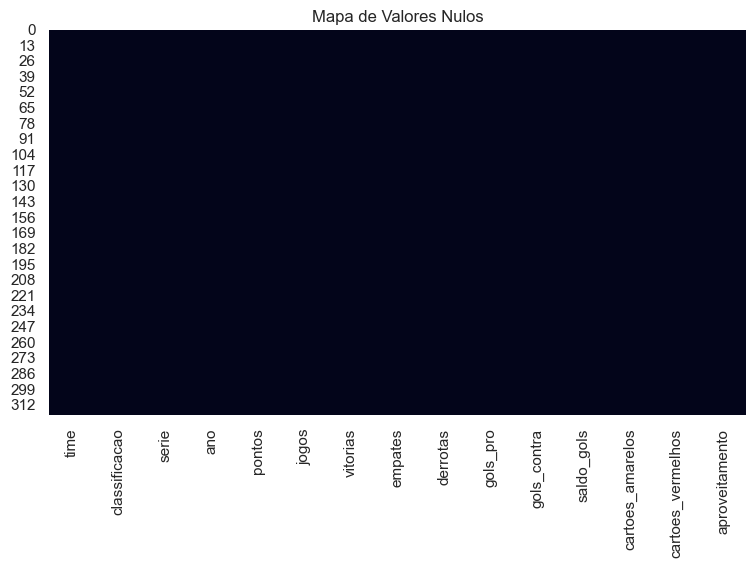

In [47]:
df.isnull().sum().sort_values(ascending=False)
sns.heatmap(df.isnull(), cbar=False)
plt.title("Mapa de Valores Nulos");  # savefig("nulos.png")


In [48]:
display(df["serie"].value_counts())
display(df.groupby("ano")["serie"].value_counts())


serie
serie-a    160
serie-b    160
Name: count, dtype: int64

ano   serie  
2018  serie-a    20
      serie-b    20
2019  serie-a    20
      serie-b    20
2020  serie-a    20
      serie-b    20
2021  serie-a    20
      serie-b    20
2022  serie-a    20
      serie-b    20
2023  serie-a    20
      serie-b    20
2024  serie-a    20
      serie-b    20
2025  serie-a    20
      serie-b    20
Name: count, dtype: int64

In [49]:
df["ano"].min(), df["ano"].max()


(np.int64(2018), np.int64(2025))

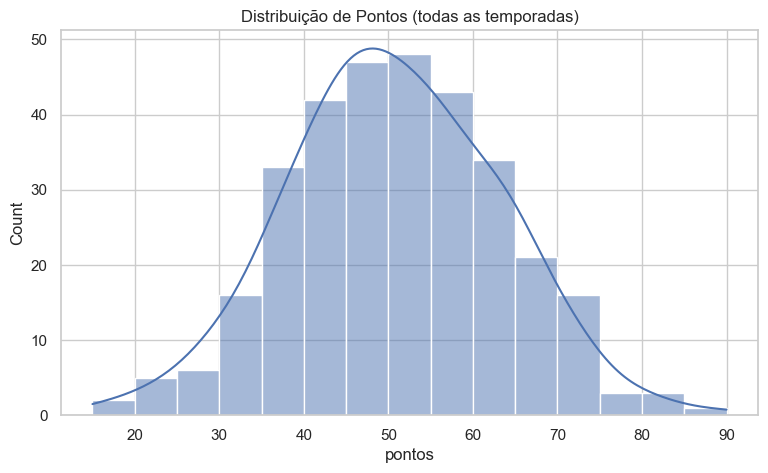

In [50]:
sns.histplot(df["pontos"], bins=15, kde=True)
plt.title("Distribuição de Pontos (todas as temporadas)");
# savefig("hist_pontos.png")


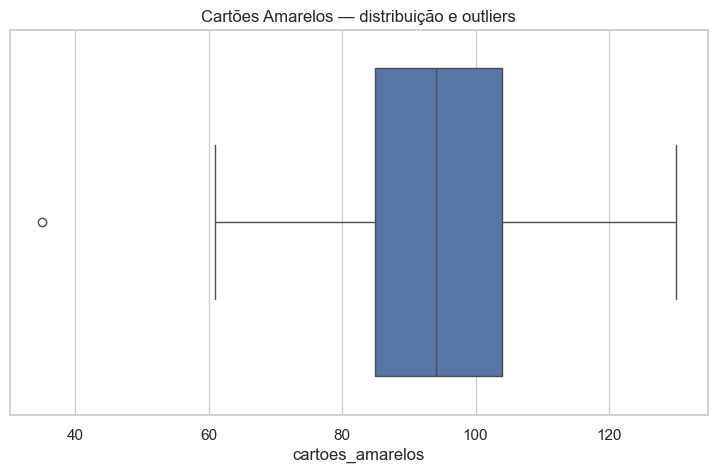

In [51]:
sns.boxplot(x=df["cartoes_amarelos"])
plt.title("Cartões Amarelos — distribuição e outliers");
# savefig("box_amarelos.png")


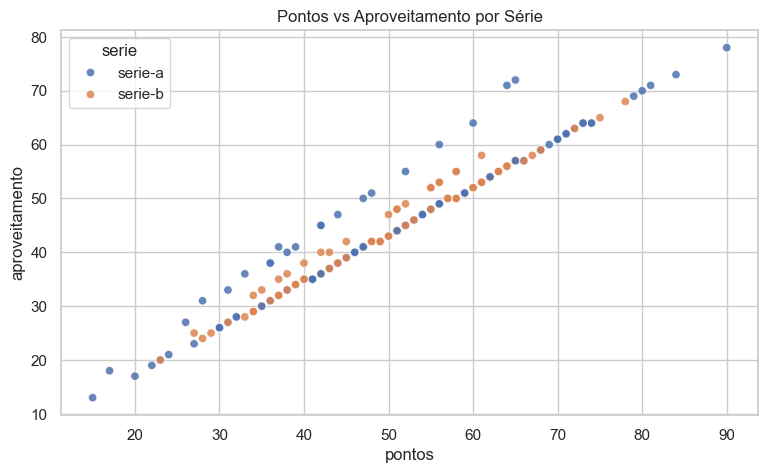

In [52]:
sns.scatterplot(data=df, x="pontos", y="aproveitamento", hue="serie", alpha=0.85)
plt.title("Pontos vs Aproveitamento por Série");
# savefig("scatter_pontos_aprov.png")


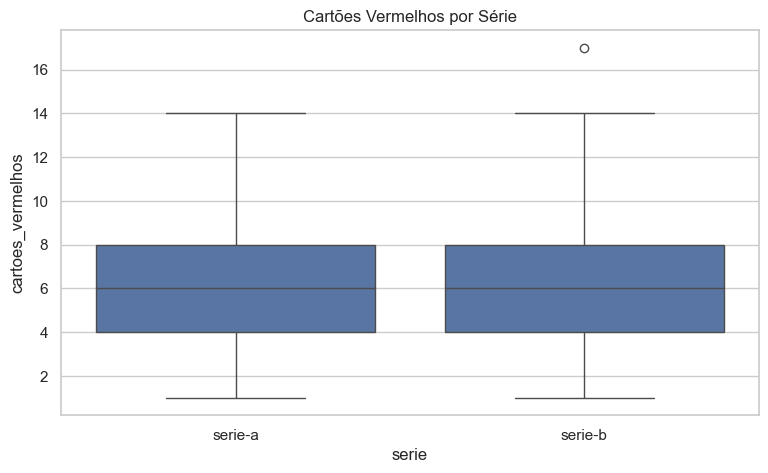

In [53]:
sns.boxplot(data=df, x="serie", y="cartoes_vermelhos")
plt.title("Cartões Vermelhos por Série");
# savefig("box_vermelhos_serie.png")


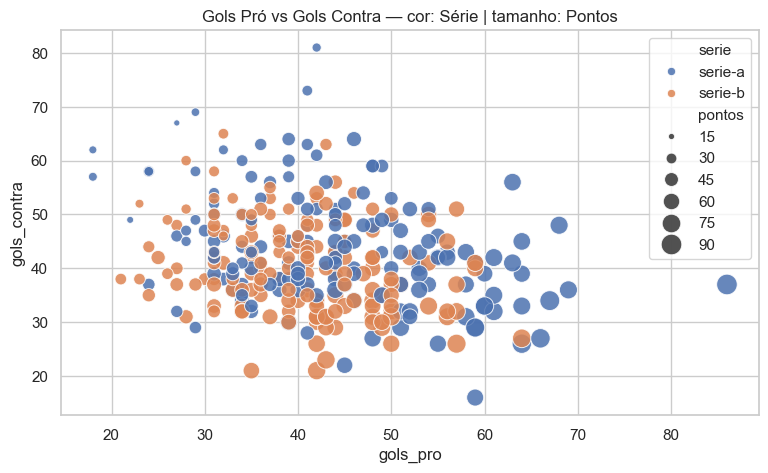

In [54]:
sns.scatterplot(
    data=df,
    x="gols_pro",
    y="gols_contra",
    hue="serie",
    size="pontos",
    sizes=(20, 220),
    alpha=0.85
)
plt.title("Gols Pró vs Gols Contra — cor: Série | tamanho: Pontos");
# savefig("multi_gp_gc_pontos.png")


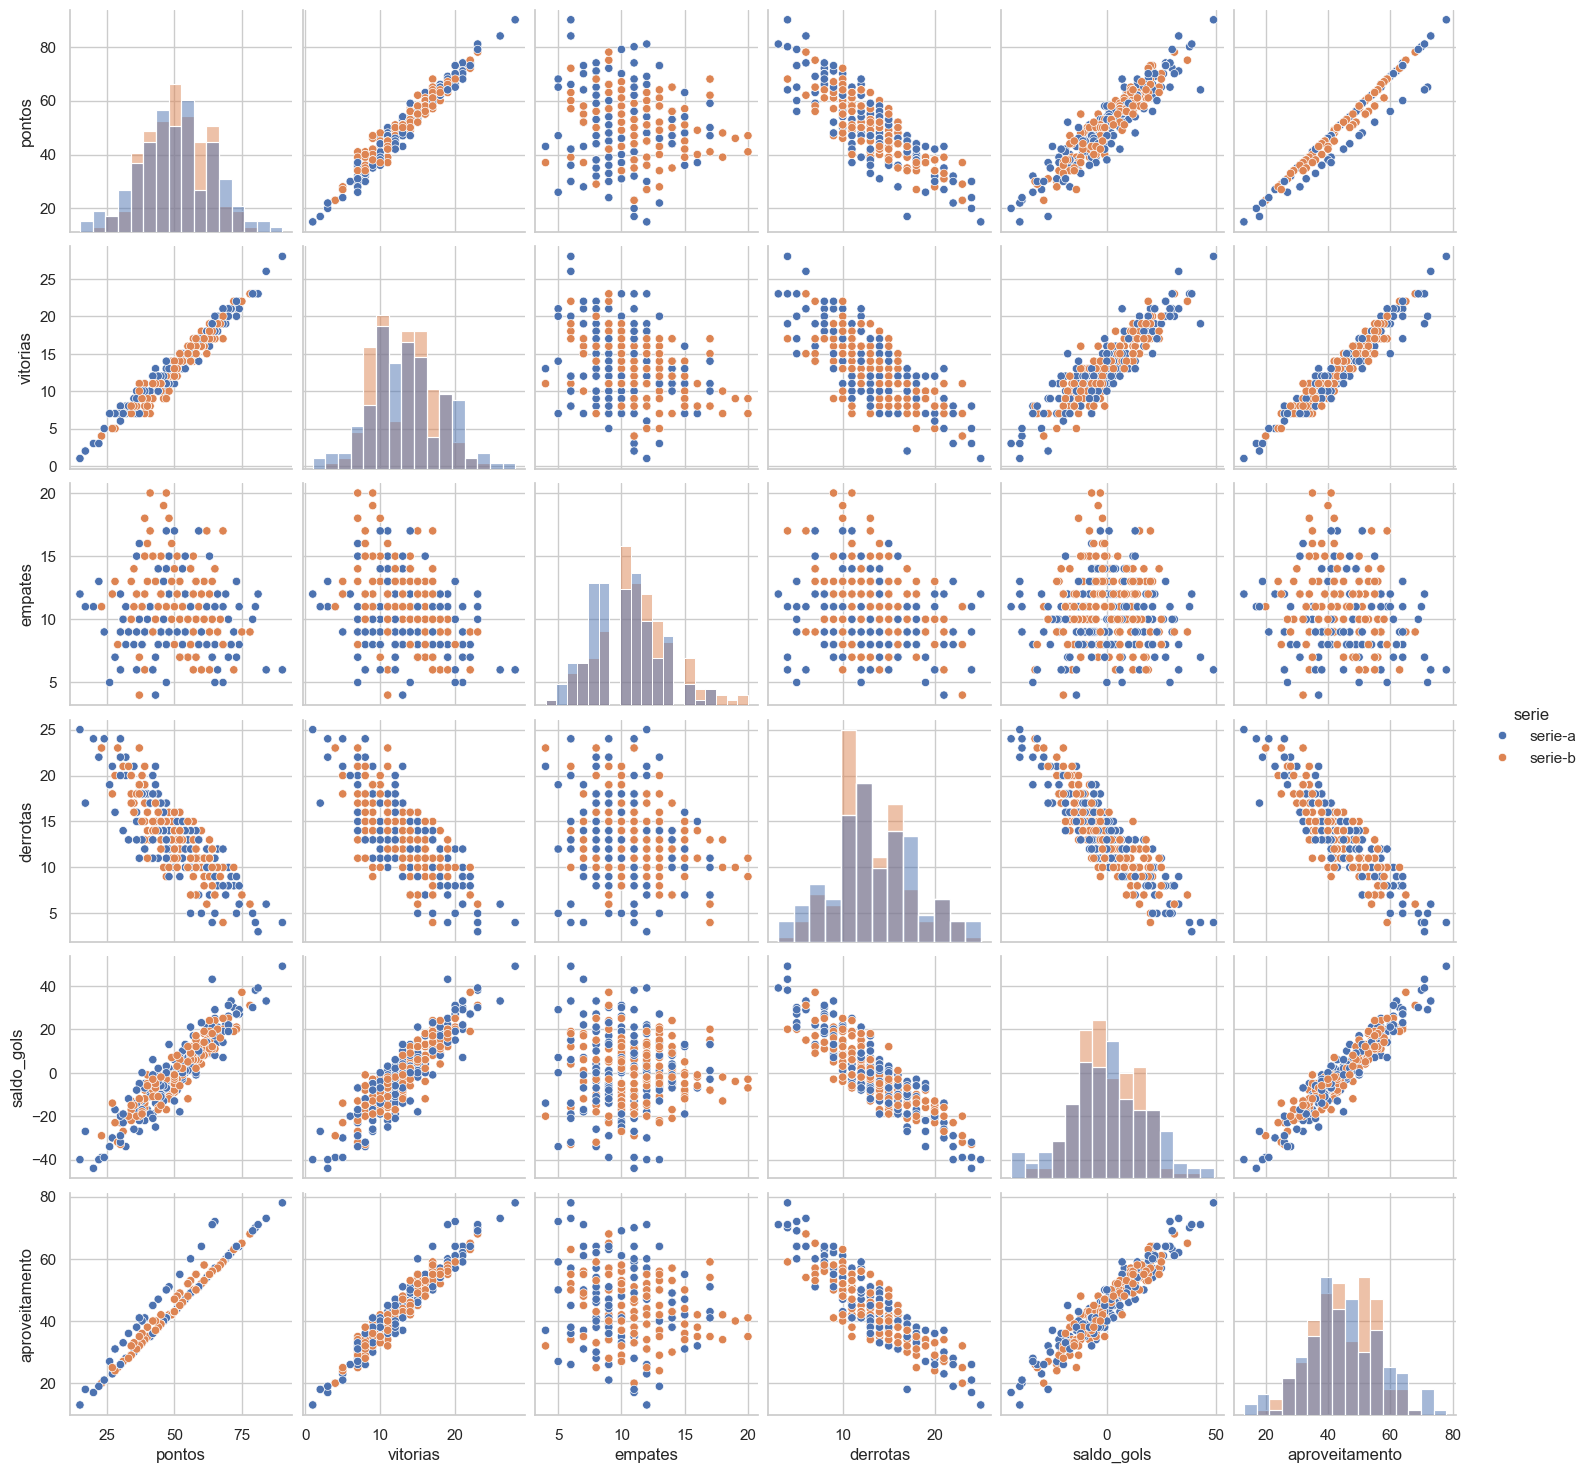

In [55]:
cols = ["pontos","vitorias","empates","derrotas","saldo_gols","aproveitamento"]
sns.pairplot(df[cols + ["serie"]], hue="serie", diag_kind="hist")


Após normalizar as variáveis pelo número de jogos, observa-se que o desempenho médio dos clubes brasileiros entre 2018 e 2025 é consistente com a realidade do campeonato: cerca de 1,3 ponto e 1 gol marcado por jogo, sofrendo também 1 gol, o que reflete equilíbrio competitivo.
A disciplina apresenta média de 2,5 cartões amarelos por partida e um cartão vermelho a cada 5–6 jogos, com pouca dispersão, indicando que o comportamento disciplinar é relativamente uniforme entre os clubes.
Os outliers em pontos por jogo (>2.0) e gols marcados (>2.0/jogo) representam as campanhas de times campeões ou dominantes, enquanto valores muito baixos refletem temporadas de rebaixamento

In [56]:
df = df.copy()
df["pontos_por_jogo"] = df["pontos"] / df["jogos"]
df["gols_pro_por_jogo"] = df["gols_pro"] / df["jogos"]
df["gols_contra_por_jogo"] = df["gols_contra"] / df["jogos"]
df["amarelos_por_jogo"] = df["cartoes_amarelos"] / df["jogos"]
df["vermelhos_por_jogo"] = df["cartoes_vermelhos"] / df["jogos"]

df[["pontos_por_jogo","gols_pro_por_jogo","gols_contra_por_jogo","amarelos_por_jogo","vermelhos_por_jogo"]].describe()


,pontos_por_jogo,gols_pro_por_jogo,gols_contra_por_jogo,amarelos_por_jogo,vermelhos_por_jogo
count,320.000000,320.000000,320.000000,320.000000,320.000000
mean,1.355657,1.127556,1.127519,2.527543,0.168174
std,0.330224,0.273829,0.255210,0.359392,0.076346
min,0.394737,0.473684,0.533333,0.921053,0.026316
25%,1.154135,0.921053,0.947368,2.282895,0.105263
50%,1.342105,1.105263,1.105263,2.500000,0.157895
75%,1.584211,1.289474,1.289474,2.789474,0.210526
max,2.368421,2.263158,2.131579,3.421053,0.447368
